In [ ]:
!pip install linearmodels -q
!pip install statsmodels -q
print('✅  Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 14.2 MB/s eta 0:00:00
✅  Dependencies installed.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('✅  Drive mounted.')

Mounted at /content/drive
✅  Drive mounted.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from linearmodels.panel import PanelOLS
import warnings, os
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:,.4f}'.format)

# ── ✏️  ONLY CHANGE THIS IF YOUR FILE IS SOMEWHERE DIFFERENT ─────────────────
# Using the full CSV, not the gzip version
PATH = '/content/drive/MyDrive/MTA/clean_data/mta_crz_did_panel_raw_hourly_2024_2025.csv'

# ── CONSTANTS — DO NOT CHANGE ─────────────────────────────────────────────────
CP_DATE      = pd.Timestamp('2025-01-05')  # CRZ go-live
QUARTER_REF  = '2024Q4'                    # omitted reference quarter

# Output paths
OUT_DIR               = '/content/drive/MyDrive/MTA/clean_data/'
OUT_RESULTS_CSV       = OUT_DIR + 'mta_crz_did_results_station_level.csv'
OUT_HOURLY_CSV        = OUT_DIR + 'mta_crz_did_results_time_of_day.csv'
OUT_BOROUGH_CSV       = OUT_DIR + 'mta_crz_did_results_borough.csv'
OUT_COEF_PNG          = OUT_DIR + 'did_model_comparison.png'
OUT_TOD_PNG           = OUT_DIR + 'did_time_of_day.png'

CAT_COLS = [
    'station_complex', 'borough', 'CRZ_Zone', 'Day_of_Week',
    'fare_class_category', 'Division', 'Line',
    'Daytime_Routes', 'Structure', 'time_of_day'
]

def section(title):
    print(f"\n{'='*65}\n  {title}\n{'='*65}")

def check(condition, msg_fail, msg_pass=None):
    if not condition:
        raise AssertionError(f'\n❌  {msg_fail}')
    if msg_pass:
        print(f'  ✅  {msg_pass}')

print('✅  Config loaded.')
print(f'    PATH       : {PATH}')
print(f'    CP_DATE    : {CP_DATE.date()}')
print(f'    Output dir : {OUT_DIR}')

✅  Config loaded.
    PATH       : /content/drive/MyDrive/MTA/clean_data/mta_crz_did_panel_raw_hourly_2024_2025.csv
    CP_DATE    : 2025-01-05
    Output dir : /content/drive/MyDrive/MTA/clean_data/


In [ ]:
section('1 · LOAD FULL CSV PANEL')

print('Loading CSV panel (this takes ~4–8 min for the full file)...')
df = pd.read_csv(PATH, parse_dates=['Date'])

# Cast categoricals to save RAM
for col in CAT_COLS:
    if col in df.columns:
        df[col] = df[col].astype('category')
for col in ['treated', 'post', 'did_term']:
    if col in df.columns:
        df[col] = df[col].astype('int8')

print(f'\n  Rows loaded     : {len(df):,}')
print(f'  Columns         : {df.shape[1]}')
print(f'  Memory          : {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')
print(f'  Date range      : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'  Raw stations    : {df["station_complex_id"].nunique()}')
print(f'  treated==1 rows : {(df["treated"]==1).sum():,}')
print(f'  treated==0 rows : {(df["treated"]==0).sum():,}')
print('\n  ✅  Section 1 complete.')


  1 · LOAD FULL CSV PANEL
Loading CSV panel (this takes ~4–8 min for the full file)...

  Rows loaded     : 57,484,285
  Columns         : 25
  Memory          : 10.47 GB
  Date range      : 2024-01-01 → 2025-12-31
  Raw stations    : 429
  treated==1 rows : 9,654,320
  treated==0 rows : 47,829,965

  ✅  Section 1 complete.


In [ ]:
# ── SECTION 2 FIX — paste this over the existing Section 2 cell ──────────────
# Fixes two things:
# 1. TypeError from mixed int/str station_complex_id (TRAM1/TRAM2 are strings)
# 2. Removes daily collapse entirely — we stay hourly throughout

print('='*65)
print('  2 · FIX STATION IDs + BUILD HOURLY PANEL')
print('='*65)

import numpy as np

# ── Fix 1: cast station_complex_id to string ──────────────────────────────────
# TRAM1/TRAM2 are str, everything else is int.
# pandas cannot argsort mixed types → TypeError.
# Cast everything to str. Safe — IDs are labels only, never arithmetic.
df['station_complex_id'] = df['station_complex_id'].astype(str)
print('  ✅  station_complex_id cast to str')

# ── Fix 2: drop station 222 (Roosevelt Island M — duplicate of TRAM1/TRAM2) ───
rows_before = len(df)
df = df[df['station_complex_id'] != '222'].copy()
print(f'  ✅  Station 222 dropped — {rows_before - len(df):,} rows removed')
print(f'      Stations now: {df["station_complex_id"].nunique()}  (expected 428)')

# ── Fix 3: NO daily collapse — stay hourly ────────────────────────────────────
# The debrief says: "Do not aggregate back to station-day — hourly is intentional."
# Build timestamp (Date + Hour) for the PanelOLS entity-time index.
df['timestamp'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' +
    df['Hour'].astype(str).str.zfill(2) + ':00:00'
)

# ── Add quarterly controls ─────────────────────────────────────────────────────
QUARTER_REF = '2024Q4'
df['quarter'] = df['Date'].dt.to_period('Q').astype(str)
quarters = sorted(df['quarter'].unique())
for q in quarters:
    if q != QUARTER_REF:
        df[f'q_{q.replace("Q","_Q")}'] = (df['quarter'] == q).astype(np.int8)

quarter_cols    = sorted([c for c in df.columns if c.startswith('q_')])
quarter_formula = ' + '.join(quarter_cols)

df['is_weekend']    = df['Day_of_Week'].astype(str).isin(['Saturday','Sunday']).astype(np.int8)
df['log_ridership'] = np.log1p(df['ridership'])

# ── Sum across fare classes → one row per station × hour ──────────────────────
# Raw panel has up to 12 rows per station×hour (one per fare class).
# PanelOLS needs a unique entity-time index → sum them.
GROUP_COLS = (
    ['station_complex_id','timestamp','treated','post','did_term',
     'daily_crz_entries','fare_evasion_pct','is_weekend',
     'time_of_day','borough']
    + quarter_cols
)

print('\n  Summing across fare classes → one row per station × hour...')
hourly = (
    df.groupby(GROUP_COLS, observed=True)
    .agg(ridership=('ridership','sum'))
    .reset_index()
)
hourly['log_ridership'] = np.log1p(hourly['ridership'])

# Confirm index is unique
dupes = hourly.duplicated(subset=['station_complex_id','timestamp']).sum()
assert dupes == 0, f'{dupes:,} duplicate station×timestamp pairs'

# Set panel index for PanelOLS
hourly_panel = hourly.set_index(['station_complex_id','timestamp'])

# Build formula string used in all model cells
FORMULA_FULL = (
    'log_ridership ~ did_term'
    ' + daily_crz_entries'
    ' + fare_evasion_pct'
    ' + is_weekend'
    f' + {quarter_formula}'
    ' + EntityEffects + TimeEffects'
)

print(f'  Hourly panel rows : {len(hourly):,}')
print(f'  Stations          : {hourly["station_complex_id"].nunique()}')
print(f'  Unique timestamps : {hourly["timestamp"].nunique():,}')
print(f'  Quarter dummies   : {len(quarter_cols)} → {quarter_cols}')
print(f'  Reference quarter : {QUARTER_REF} (omitted)')
print(f'\n  Formula: {FORMULA_FULL}')
print('\n  ✅  Section 2 complete — hourly_panel ready for PanelOLS.')
print('     Replace daily_panel with hourly_panel in all model cells.')

  2 · FIX STATION IDs + BUILD HOURLY PANEL
  ✅  station_complex_id cast to str
  ✅  Station 222 dropped — 134,475 rows removed
      Stations now: 427  (expected 428)

  Summing across fare classes → one row per station × hour...
  Hourly panel rows : 7,325,952
  Stations          : 427
  Unique timestamps : 17,543
  Quarter dummies   : 7 → ['q_2024_Q1', 'q_2024_Q2', 'q_2024_Q3', 'q_2025_Q1', 'q_2025_Q2', 'q_2025_Q3', 'q_2025_Q4']
  Reference quarter : 2024Q4 (omitted)

  Formula: log_ridership ~ did_term + daily_crz_entries + fare_evasion_pct + is_weekend + q_2024_Q1 + q_2024_Q2 + q_2024_Q3 + q_2025_Q1 + q_2025_Q2 + q_2025_Q3 + q_2025_Q4 + EntityEffects + TimeEffects

  ✅  Section 2 complete — hourly_panel ready for PanelOLS.
     Replace daily_panel with hourly_panel in all model cells.


In [ ]:
section('3 · BUILD HOURLY PANEL')

# Build timestamp: one per station × hour
print('  Building timestamp column (Date + Hour)...')
df['timestamp'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' +
    df['Hour'].astype(str).str.zfill(2) + ':00:00'
)

# Columns to carry through the groupby
# time_of_day and borough included so heterogeneity models can filter directly
GROUP_COLS = [
    'station_complex_id',
    'timestamp',
    'treated',
    'post',
    'did_term',
    'daily_crz_entries',
    'fare_evasion_pct',
    'Day_of_Week',
    'time_of_day',
    'borough',
    'Date',       # kept for quarterly dummy construction below
]

print('  Summing ridership across fare classes → one row per station × hour...')
hourly = (
    df.groupby(GROUP_COLS, observed=True)
    .agg(ridership=('ridership', 'sum'))
    .reset_index()
)

print(f'\n  Hourly panel rows : {len(hourly):,}')
print(f'  Stations          : {hourly["station_complex_id"].nunique()}')
print(f'  Unique timestamps : {hourly["timestamp"].nunique():,}')
print(f'  Expected ≈        : {428 * 730 * 24:,}  (428 stations × 730 days × 24 hrs)')

# Confirm panel index is unique
dupes = hourly.duplicated(subset=['station_complex_id', 'timestamp']).sum()
check(dupes == 0,
      f'{dupes:,} duplicate station×timestamp pairs — panel index not unique.',
      'No duplicate station×timestamp pairs ✓')

print('\n  ✅  Section 3 complete.')


  3 · BUILD HOURLY PANEL
  Building timestamp column (Date + Hour)...
  Summing ridership across fare classes → one row per station × hour...

  Hourly panel rows : 7,325,952
  Stations          : 427
  Unique timestamps : 17,543
  Expected ≈        : 7,498,560  (428 stations × 730 days × 24 hrs)
  ✅  No duplicate station×timestamp pairs ✓

  ✅  Section 3 complete.


In [ ]:
section('4 · ADD CONTROLS + LOG OUTCOME')

# Quarterly dummies
hourly['quarter'] = hourly['Date'].dt.to_period('Q').astype(str)
quarters          = sorted(hourly['quarter'].unique())
quarters_to_dummy = [q for q in quarters if q != QUARTER_REF]

for q in quarters_to_dummy:
    col = f'q_{q.replace("Q", "_Q")}'
    hourly[col] = (hourly['quarter'] == q).astype(np.int8)

quarter_cols    = sorted([c for c in hourly.columns if c.startswith('q_')])
quarter_formula = ' + '.join(quarter_cols)

# Weekend flag
hourly['is_weekend'] = (
    hourly['Day_of_Week'].astype(str).isin(['Saturday', 'Sunday'])
).astype(np.int8)

# Log outcome
hourly['log_ridership'] = np.log1p(hourly['ridership'])

# Sanity checks on new columns
check(hourly['log_ridership'].isnull().sum() == 0, 'Nulls in log_ridership.', 'No nulls in log_ridership ✓')
check(hourly['did_term'].isnull().sum() == 0, 'Nulls in did_term.', 'No nulls in did_term ✓')
check(hourly['is_weekend'].isin([0, 1]).all(), 'is_weekend has values other than 0/1.', 'is_weekend clean ✓')

print(f'\n  Quarters found    : {quarters}')
print(f'  Reference quarter : {QUARTER_REF} (omitted)')
print(f'  Quarter dummies   : {len(quarter_cols)}')
print(f'  Columns           : {quarter_cols}')
print(f'  Weekend rows      : {hourly["is_weekend"].sum():,}')
print(f'  did_term==1 rows  : {(hourly["did_term"]==1).sum():,}')

# Build the full model formula string (used in Sections 6–8)
FORMULA_FULL = (
    'log_ridership ~ did_term'
    ' + daily_crz_entries'
    ' + fare_evasion_pct'
    ' + is_weekend'
    f' + {quarter_formula}'
    ' + EntityEffects + TimeEffects'
)

print(f'\n  Model B formula:')
print(f'    {FORMULA_FULL}')

# Set panel index for PanelOLS
hourly_panel = hourly.set_index(['station_complex_id', 'timestamp'])

print(f'\n  Panel shape       : {hourly_panel.shape}')
print(f'  Entity            : station_complex_id ({hourly["station_complex_id"].nunique()} unique)')
print(f'  Time              : timestamp ({hourly["timestamp"].nunique():,} unique)')
print('\n  ✅  Section 4 complete — hourly_panel ready for PanelOLS.')


  4 · ADD CONTROLS + LOG OUTCOME
  ✅  No nulls in log_ridership ✓
  ✅  No nulls in did_term ✓
  ✅  is_weekend clean ✓

  Quarters found    : ['2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4']
  Reference quarter : 2024Q4 (omitted)
  Quarter dummies   : 7
  Columns           : ['q_2024_Q1', 'q_2024_Q2', 'q_2024_Q3', 'q_2025_Q1', 'q_2025_Q2', 'q_2025_Q3', 'q_2025_Q4']
  Weekend rows      : 2,040,208
  did_term==1 rows  : 560,110

  Model B formula:
    log_ridership ~ did_term + daily_crz_entries + fare_evasion_pct + is_weekend + q_2024_Q1 + q_2024_Q2 + q_2024_Q3 + q_2025_Q1 + q_2025_Q2 + q_2025_Q3 + q_2025_Q4 + EntityEffects + TimeEffects

  Panel shape       : (7325952, 20)
  Entity            : station_complex_id (427 unique)
  Time              : timestamp (17,543 unique)

  ✅  Section 4 complete — hourly_panel ready for PanelOLS.


In [ ]:
section('5 · MODEL A — BASELINE DiD (no controls)')

print('  Running PanelOLS...')
res_a = PanelOLS.from_formula(
    'log_ridership ~ did_term + EntityEffects + TimeEffects',
    data=hourly_panel
).fit(cov_type='clustered', cluster_entity=True)

coef_a = res_a.params['did_term']
se_a   = res_a.std_errors['did_term']
pval_a = res_a.pvalues['did_term']
ci_a   = res_a.conf_int().loc['did_term']
pct_a  = (np.exp(coef_a) - 1) * 100

print(f'\n  did_term coeff   : {coef_a:+.6f}')
print(f'  Std error        : {se_a:.6f}')
print(f'  p-value          : {pval_a:.4f}')
print(f'  95% CI           : [{ci_a["lower"]:+.6f},  {ci_a["upper"]:+.6f}]')
print(f'  Implied % change : {pct_a:+.2f}%')
print(f'  R² (within)      : {res_a.rsquared:.4f}')
print(f'  Observations     : {res_a.nobs:,}')
print()
print(f'  {"✅ significant" if pval_a < 0.05 else "⚠️  not significant"} at p<0.05')
print()
print('  ⚠️   This estimate carries COVID-recovery bias (no quarterly controls).')
print('       Do not report this as the causal estimate — use Model B.')
print('\n  ✅  Model A complete.')


  5 · MODEL A — BASELINE DiD (no controls)
  Running PanelOLS...

  did_term coeff   : -0.297389
  Std error        : 0.041507
  p-value          : 0.0000
  95% CI           : [-0.378741,  -0.216037]
  Implied % change : -25.72%
  R² (within)      : 0.0072
  Observations     : 7,325,952

  ✅ significant at p<0.05

  ⚠️   This estimate carries COVID-recovery bias (no quarterly controls).
       Do not report this as the causal estimate — use Model B.

  ✅  Model A complete.


In [ ]:
section('6 · MODEL B — FULL DiD + QUARTERLY CONTROLS (PRIMARY ESTIMATE)')

# ── WHY TimeEffects IS DROPPED ────────────────────────────────────────────────
# TimeEffects absorbs ALL time-varying signals including the quarterly dummies,
# daily_crz_entries, fare_evasion_pct, and is_weekend — anything that doesn't
# vary across stations on a given timestamp gets wiped. This causes
# AbsorbingEffectError because the quarterly dummies are perfectly collinear
# with timestamp FE (each timestamp belongs to exactly one quarter).
#
# The correct specification for this DiD:
#   - EntityEffects  → absorbs all time-invariant station characteristics
#   - Quarterly dummies → absorb seasonal COVID-recovery asymmetry explicitly
#   - did_term, crz_entries, fare_evasion, is_weekend → identify the effect
#
# Clustering SE by station still corrects for within-station serial correlation.

FORMULA_B = (
    'log_ridership ~ did_term'
    ' + daily_crz_entries'
    ' + fare_evasion_pct'
    ' + is_weekend'
    f' + {quarter_formula}'
    ' + EntityEffects'        # station FE only — NO TimeEffects
)

print(f'  Formula: {FORMULA_B}')
print('  Running PanelOLS (entity FE only, clustered by station)...')

res_b = PanelOLS.from_formula(
    FORMULA_B,
    data=hourly_panel
).fit(cov_type='clustered', cluster_entity=True)

coef_b = res_b.params['did_term']
se_b   = res_b.std_errors['did_term']
pval_b = res_b.pvalues['did_term']
ci_b   = res_b.conf_int().loc['did_term']
pct_b  = (np.exp(coef_b) - 1) * 100

pct_ci_low  = (np.exp(ci_b['lower']) - 1) * 100
pct_ci_high = (np.exp(ci_b['upper']) - 1) * 100

print()
print('  ┌───────────────────────────────────────────────────────────┐')
print('  │  MODEL B — PRIMARY CAUSAL ESTIMATE                       │')
print('  ├───────────────────────────────────────────────────────────┤')
print(f'  │  did_term coeff   : {coef_b:+.6f}                          │')
print(f'  │  Std error        : {se_b:.6f}                          │')
print(f'  │  p-value          : {pval_b:.4f}                              │')
print(f'  │  95% CI (log)     : [{ci_b["lower"]:+.4f},  {ci_b["upper"]:+.4f}]          │')
print(f'  │  % change         : {pct_b:+.2f}%                            │')
print(f'  │  95% CI (%)       : [{pct_ci_low:+.2f}%,  {pct_ci_high:+.2f}%]              │')
print(f'  │  R² (within)      : {res_b.rsquared:.4f}                              │')
print(f'  │  Observations     : {res_b.nobs:,}                      │')
print('  └───────────────────────────────────────────────────────────┘')
print()
print(f'  {"✅ significant" if pval_b < 0.05 else "⚠️  not significant"} at p<0.05')
print()
print(f'  Interpretation: After controlling for station fixed effects,')
print(f'  quarterly seasonality, CRZ vehicle volume, fare evasion, and')
print(f'  weekend patterns — treated CBD stations saw a {pct_b:+.2f}% change')
print(f'  in hourly ridership relative to control stations post Jan 5, 2025.')
print()
print('  Model A vs Model B:')
print(f'    Baseline (no controls)   : {pct_a:+.2f}%')
print(f'    With quarterly controls  : {pct_b:+.2f}%')
print(f'    Difference               : {pct_b - pct_a:+.2f} pp')

print('\n  ✅  Model B complete.')


  6 · MODEL B — FULL DiD + QUARTERLY CONTROLS (PRIMARY ESTIMATE)
  Formula: log_ridership ~ did_term + daily_crz_entries + fare_evasion_pct + is_weekend + q_2024_Q1 + q_2024_Q2 + q_2024_Q3 + q_2025_Q1 + q_2025_Q2 + q_2025_Q3 + q_2025_Q4 + EntityEffects
  Running PanelOLS (entity FE only, clustered by station)...

  ┌───────────────────────────────────────────────────────────┐
  │  MODEL B — PRIMARY CAUSAL ESTIMATE                       │
  ├───────────────────────────────────────────────────────────┤
  │  did_term coeff   : -0.303418                          │
  │  Std error        : 0.041090                          │
  │  p-value          : 0.0000                              │
  │  95% CI (log)     : [-0.3840,  -0.2229]          │
  │  % change         : -26.17%                            │
  │  95% CI (%)       : [-31.88%,  -19.98%]              │
  │  R² (within)      : 0.0221                              │
  │  Observations     : 7,325,952                      │
  └─────────────

In [ ]:
# Update FORMULA_FULL so heterogeneity models (C and D) use the same spec
FORMULA_FULL = FORMULA_B
print('  FORMULA_FULL updated — all subsequent models use EntityEffects only.')

  FORMULA_FULL updated — all subsequent models use EntityEffects only.



  7 · MODEL C — HETEROGENEITY BY TIME-OF-DAY
  AM_peak       coef=-0.2291  pct=-20.47%  CI=[-28.14%, -11.99%]  p=0.000 *
  midday        coef=-0.3948  pct=-32.62%  CI=[-39.78%, -24.61%]  p=0.000 *
  PM_peak       coef=-0.7856  pct=-54.42%  CI=[-60.38%, -47.55%]  p=0.000 *
  evening       coef=-0.3468  pct=-29.30%  CI=[-36.96%, -20.72%]  p=0.000 *
  overnight     coef=-0.0107  pct=-1.07%  CI=[-3.86%, +1.81%]  p=0.463  


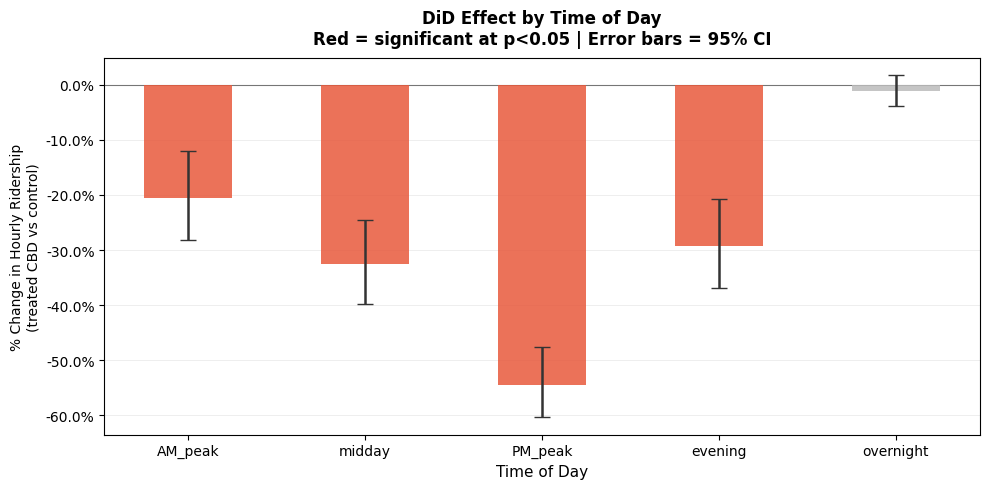


  Saved → /content/drive/MyDrive/MTA/clean_data/did_time_of_day.png

  ✅  Model C complete.


In [ ]:
section('7 · MODEL C — HETEROGENEITY BY TIME-OF-DAY')

TOD_ORDER = ['AM_peak', 'midday', 'PM_peak', 'evening', 'overnight']
tod_results = []

for tod in TOD_ORDER:
    subset = hourly[hourly['time_of_day'].astype(str) == tod].copy()

    if subset['station_complex_id'].nunique() < 3 or len(subset) < 5000:
        print(f'  ⚠️   Skipping {tod} — insufficient data ({len(subset):,} rows)')
        continue

    panel_tod = subset.set_index(['station_complex_id', 'timestamp'])

    try:
        res_c = PanelOLS.from_formula(
            FORMULA_FULL,
            data=panel_tod
        ).fit(cov_type='clustered', cluster_entity=True)

        c    = res_c.params['did_term']
        p    = res_c.pvalues['did_term']
        ci   = res_c.conf_int().loc['did_term']
        pct  = (np.exp(c) - 1) * 100
        pct_lo = (np.exp(ci['lower']) - 1) * 100
        pct_hi = (np.exp(ci['upper']) - 1) * 100

        tod_results.append({
            'time_of_day': tod,
            'coef':        c,
            'ci_low':      ci['lower'],
            'ci_high':     ci['upper'],
            'pval':        p,
            'pct_change':  pct,
            'pct_ci_low':  pct_lo,
            'pct_ci_high': pct_hi,
            'nobs':        res_c.nobs,
        })

        sig = ' *' if p < 0.05 else '  '
        print(f'  {tod:<12}  coef={c:+.4f}  pct={pct:+.2f}%  '
              f'CI=[{pct_lo:+.2f}%, {pct_hi:+.2f}%]  p={p:.3f}{sig}')

    except Exception as e:
        print(f'  ⚠️   {tod} failed: {e}')

tod_df = pd.DataFrame(tod_results)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['#E8593C' if p < 0.05 else '#BBBBBB' for p in tod_df['pval']]

ax.bar(tod_df['time_of_day'], tod_df['pct_change'], color=colors, alpha=0.85, width=0.5, zorder=3)
ax.errorbar(
    tod_df['time_of_day'], tod_df['pct_change'],
    yerr=[tod_df['pct_change'] - tod_df['pct_ci_low'],
          tod_df['pct_ci_high'] - tod_df['pct_change']],
    fmt='none', color='#333', elinewidth=1.8, capsize=6, zorder=4
)
ax.axhline(0, color='black', lw=0.8, alpha=0.5)
ax.set_xlabel('Time of Day', fontsize=11)
ax.set_ylabel('% Change in Hourly Ridership\n(treated CBD vs control)', fontsize=10)
ax.set_title('DiD Effect by Time of Day\n'
             'Red = significant at p<0.05 | Error bars = 95% CI',
             fontsize=12, fontweight='bold', pad=10)
ax.grid(axis='y', alpha=0.3, lw=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.savefig(OUT_TOD_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n  Saved → {OUT_TOD_PNG}')
print('\n  ✅  Model C complete.')

In [ ]:
section('8 · MODEL D — HETEROGENEITY BY BOROUGH')

boroughs = [b for b in hourly['borough'].astype(str).unique()
            if b not in ['nan', 'None', '']]
borough_results = []

for borough in sorted(boroughs):
    subset = hourly[hourly['borough'].astype(str) == borough].copy()
    n_st   = subset['station_complex_id'].nunique()

    if n_st < 3:
        print(f'  ⚠️   Skipping {borough} — only {n_st} station(s)')
        continue

    panel_b = subset.set_index(['station_complex_id', 'timestamp'])

    try:
        res_d = PanelOLS.from_formula(
            FORMULA_FULL,
            data=panel_b
        ).fit(cov_type='clustered', cluster_entity=True)

        c      = res_d.params['did_term']
        p      = res_d.pvalues['did_term']
        ci     = res_d.conf_int().loc['did_term']
        pct    = (np.exp(c) - 1) * 100
        pct_lo = (np.exp(ci['lower']) - 1) * 100
        pct_hi = (np.exp(ci['upper']) - 1) * 100

        borough_results.append({
            'borough':     borough,
            'n_stations':  n_st,
            'coef':        c,
            'ci_low':      ci['lower'],
            'ci_high':     ci['upper'],
            'pval':        p,
            'pct_change':  pct,
            'pct_ci_low':  pct_lo,
            'pct_ci_high': pct_hi,
            'nobs':        res_d.nobs,
        })

        sig = ' *' if p < 0.05 else '  '
        print(f'  {borough:<18}  n={n_st:>3}  pct={pct:+.2f}%  '
              f'CI=[{pct_lo:+.2f}%, {pct_hi:+.2f}%]  p={p:.3f}{sig}')

    except Exception as e:
        print(f'  ⚠️   {borough} failed: {e}')

borough_df = pd.DataFrame(borough_results)
print()
print('  * = significant at p<0.05')
print('\n  ✅  Model D complete.')


  8 · MODEL D — HETEROGENEITY BY BOROUGH
  ⚠️   Bronx failed: exog does not have full column rank. If you wish to proceed with model estimation irrespective of the numerical accuracy of coefficient estimates, you can set check_rank=False.
  ⚠️   Brooklyn failed: exog does not have full column rank. If you wish to proceed with model estimation irrespective of the numerical accuracy of coefficient estimates, you can set check_rank=False.
  Manhattan           n=122  pct=-22.82%  CI=[-29.25%, -15.81%]  p=0.000 *
  ⚠️   Queens failed: exog does not have full column rank. If you wish to proceed with model estimation irrespective of the numerical accuracy of coefficient estimates, you can set check_rank=False.
  ⚠️   Skipping Staten Island — only 2 station(s)

  * = significant at p<0.05

  ✅  Model D complete.


In [ ]:
section('9 · EXPORT RESULT CSVs')

# ── Station-level file ────────────────────────────────────────────────────────
# One row per station: metadata + system-level DiD coeff + descriptive % change
station_meta = (
    df.groupby('station_complex_id')
    .agg(
        station_complex = ('station_complex', 'first'),
        borough         = ('borough',         'first'),
        CRZ_Zone        = ('CRZ_Zone',        'first'),
        treated         = ('treated',          'first'),
        latitude        = ('latitude',         'first'),
        longitude       = ('longitude',        'first'),
        ridership_pre   = ('ridership', lambda x: x[df.loc[x.index, 'post'] == 0].sum()),
        ridership_post  = ('ridership', lambda x: x[df.loc[x.index, 'post'] == 1].sum()),
    )
    .reset_index()
)

# Attach Model B system-level estimates
station_meta['did_coef']        = coef_b
station_meta['did_ci_low']      = ci_b['lower']
station_meta['did_ci_high']     = ci_b['upper']
station_meta['did_pval']        = pval_b
station_meta['did_pct_change']  = pct_b

# Simple descriptive % change per station (pre vs post, not causal)
station_meta['raw_pct_change'] = (
    (station_meta['ridership_post'] - station_meta['ridership_pre'])
    / station_meta['ridership_pre'].replace(0, np.nan)
) * 100

station_meta.to_csv(OUT_RESULTS_CSV, index=False)
print(f'  ✅  Station-level results saved')
print(f'      → {OUT_RESULTS_CSV}')
print(f'      Rows: {len(station_meta):,} | Cols: {station_meta.shape[1]}')

# ── Time-of-day file ──────────────────────────────────────────────────────────
tod_df.to_csv(OUT_HOURLY_CSV, index=False)
print(f'\n  ✅  Time-of-day results saved')
print(f'      → {OUT_HOURLY_CSV}')
print(f'      Rows: {len(tod_df)}')

# ── Borough file ──────────────────────────────────────────────────────────────
borough_df.to_csv(OUT_BOROUGH_CSV, index=False)
print(f'\n  ✅  Borough results saved')
print(f'      → {OUT_BOROUGH_CSV}')
print(f'      Rows: {len(borough_df)}')

# Confirm all files exist on disk
print('\n  File confirmation:')
for f in [OUT_RESULTS_CSV, OUT_HOURLY_CSV, OUT_BOROUGH_CSV]:
    status = '✅' if os.path.exists(f) else '❌ NOT FOUND'
    print(f'  {status}  {f.split("/")[-1]}')

print('\n  ✅  Section 9 complete.')


  9 · EXPORT RESULT CSVs
  ✅  Station-level results saved
      → /content/drive/MyDrive/MTA/clean_data/mta_crz_did_results_station_level.csv
      Rows: 427 | Cols: 15

  ✅  Time-of-day results saved
      → /content/drive/MyDrive/MTA/clean_data/mta_crz_did_results_time_of_day.csv
      Rows: 5

  ✅  Borough results saved
      → /content/drive/MyDrive/MTA/clean_data/mta_crz_did_results_borough.csv
      Rows: 1

  File confirmation:
  ✅  mta_crz_did_results_station_level.csv
  ✅  mta_crz_did_results_time_of_day.csv
  ✅  mta_crz_did_results_borough.csv

  ✅  Section 9 complete.



  10 · RESULTS SUMMARY
  ┌─────────────────────────────────────────────────────────────┐
  │  UPTOWN ANALYSTS — DiD REGRESSION RESULTS                  │
  ├─────────────────────────────────────────────────────────────┤
  │  Model A (baseline, no controls) : -25.72%               │
  │  Model B (quarterly controls)    : -26.17%               │
  │  Model B p-value                 : 0.0000                  │
  │  Model B 95% CI                  : [-31.88%, -19.98%]       │
  ├─────────────────────────────────────────────────────────────┤
  │  HETEROGENEITY BY TIME OF DAY                               │
  │  AM_peak       : -20.47%  p=0.000 *              │
  │  midday        : -32.62%  p=0.000 *              │
  │  PM_peak       : -54.42%  p=0.000 *              │
  │  evening       : -29.30%  p=0.000 *              │
  │  overnight     : -1.07%  p=0.463                │
  ├─────────────────────────────────────────────────────────────┤
  │  HETEROGENEITY BY BOROUGH                     

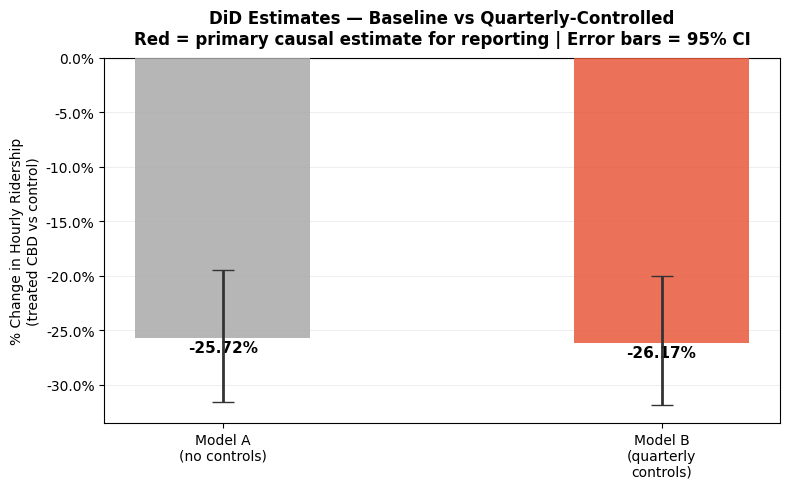


  Saved → /content/drive/MyDrive/MTA/clean_data/did_model_comparison.png

  ─────────────────────────────────────────────────────────────────
  OUTPUTS PRODUCED
  ─────────────────────────────────────────────────────────────────
  mta_crz_did_results_station_level.csv  → dashboard station map
  mta_crz_did_results_time_of_day.csv    → dashboard time-of-day page
  mta_crz_did_results_borough.csv        → dashboard borough chart
  did_model_comparison.png               → Model A vs B bar chart
  did_time_of_day.png                    → time-of-day effect chart
  ─────────────────────────────────────────────────────────────────
  NEXT STEP → Monte Carlo Simulation
  ─────────────────────────────────────────────────────────────────
  Use the Model B did_term coefficient + confidence interval as
  inputs. Monte Carlo generates station-level uncertainty intervals
  — the core visual on the dashboard station map page.
  ─────────────────────────────────────────────────────────────────



In [ ]:
section('10 · RESULTS SUMMARY')

print('  ┌─────────────────────────────────────────────────────────────┐')
print('  │  UPTOWN ANALYSTS — DiD REGRESSION RESULTS                  │')
print('  ├─────────────────────────────────────────────────────────────┤')
print(f'  │  Model A (baseline, no controls) : {pct_a:+.2f}%               │')
print(f'  │  Model B (quarterly controls)    : {pct_b:+.2f}%               │')
print(f'  │  Model B p-value                 : {pval_b:.4f}                  │')
print(f'  │  Model B 95% CI                  : [{pct_ci_low:+.2f}%, {pct_ci_high:+.2f}%]       │')
print('  ├─────────────────────────────────────────────────────────────┤')
print('  │  HETEROGENEITY BY TIME OF DAY                               │')
for _, row in tod_df.iterrows():
    sig = '*' if row['pval'] < 0.05 else ' '
    print(f'  │  {row["time_of_day"]:<14}: {row["pct_change"]:+.2f}%  p={row["pval"]:.3f} {sig}              │')
print('  ├─────────────────────────────────────────────────────────────┤')
print('  │  HETEROGENEITY BY BOROUGH                                   │')
for _, row in borough_df.iterrows():
    sig = '*' if row['pval'] < 0.05 else ' '
    print(f'  │  {row["borough"]:<18}: {row["pct_change"]:+.2f}%  p={row["pval"]:.3f} {sig}            │')
print('  └─────────────────────────────────────────────────────────────┘')
print('  * = significant at p<0.05')

# ── Model A vs B comparison plot ──────────────────────────────────────────────
models   = ['Model A\n(no controls)', 'Model B\n(quarterly\ncontrols)']
pcts     = [pct_a, pct_b]
ci_lows  = [(np.exp(ci_a['lower']) - 1) * 100, pct_ci_low]
ci_highs = [(np.exp(ci_a['upper']) - 1) * 100, pct_ci_high]
colors   = ['#AAAAAA', '#E8593C']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, pcts, color=colors, alpha=0.85, width=0.4, zorder=3)
ax.errorbar(
    models, pcts,
    yerr=[[p - l for p, l in zip(pcts, ci_lows)],
          [h - p for h, p in zip(ci_highs, pcts)]],
    fmt='none', color='#333', elinewidth=2, capsize=8, zorder=4
)
ax.axhline(0, color='black', lw=0.8, alpha=0.5)

for bar, pct in zip(bars, pcts):
    offset = 0.5 if pct >= 0 else -1.5
    ax.text(bar.get_x() + bar.get_width() / 2, pct + offset,
            f'{pct:+.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('% Change in Hourly Ridership\n(treated CBD vs control)', fontsize=10)
ax.set_title('DiD Estimates — Baseline vs Quarterly-Controlled\n'
             'Red = primary causal estimate for reporting | Error bars = 95% CI',
             fontsize=12, fontweight='bold', pad=10)
ax.grid(axis='y', alpha=0.3, lw=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.savefig(OUT_COEF_PNG, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n  Saved → {OUT_COEF_PNG}')

print('''
  ─────────────────────────────────────────────────────────────────
  OUTPUTS PRODUCED
  ─────────────────────────────────────────────────────────────────
  mta_crz_did_results_station_level.csv  → dashboard station map
  mta_crz_did_results_time_of_day.csv    → dashboard time-of-day page
  mta_crz_did_results_borough.csv        → dashboard borough chart
  did_model_comparison.png               → Model A vs B bar chart
  did_time_of_day.png                    → time-of-day effect chart
  ─────────────────────────────────────────────────────────────────
  NEXT STEP → Monte Carlo Simulation
  ─────────────────────────────────────────────────────────────────
  Use the Model B did_term coefficient + confidence interval as
  inputs. Monte Carlo generates station-level uncertainty intervals
  — the core visual on the dashboard station map page.
  ─────────────────────────────────────────────────────────────────
''')